# Overall
```
- 프로젝트명 : 매출-수익-수익률 분석
- 프로젝트유형 : 지표 구축, 수익률 저하 이슈 분석
- 문제정의 : 저성과 원인 구체화, 해소 방안 마련
- 성과측정 :
    - 지표 제시
        - 1순위 : Sales
        - 2순위 : Rate_of_return = Profit / Sales
        - 3순위 : Profit

    - Reference
        - Rate 기준으로 접근해볼 수 있겠으나, 실질적인 매출 규모 반영이 어려운 점을 감안하여, 시장 파워를 측정할 수 있는 Sales를 1지표로 제안드립니다.

- 분석결과 / 제안
    - Sales, Profit Trend

        - Aspect 1 : Ship Mode / Aspect 2 : Segment
            - Ship Mode, Segment 측면에서의 수익률 개선안은 장기적으로 검토해봄이 좋을 것 같습니다.
            - 특정시기의 단편적 데이터 기반으로 방향성 수립 보다, 장기적인 수익률 추이 모니터링 통한 종합적 관측을 권장드립니다.

        - Aspect 3 : Region > State > City
            - Region, State, City 수준의 개선안 제안 상세입니다.
            - 선별 기준은 Sales 파워를 보유하고 있으나, 음의 수익률을 보이거나, 저조한 경우에 해당되며, 이를 개선 최우선 개선 대상으로 제안드립니다.
            - 개선 위한 다양한 시험 과정에서 Risk 최소화를 위해 City > State > Region 순으로 작은 규모 Area 대상으로 먼저 시행 및 개선 도모를 권장드립니다.
            - 더불어 대상 Area 의 성과 개선 여부 파악을 위해, 대상 영역만 filtered 된 데이터스트림을 통해 대시보드 생성을 검토해볼 수 있겠습니다.
                - Region = 'Central'
                - State = 'Texas', 'Illinois', 'Michigan', 'Indiana', 'Wisconsin', 'Minnesota', 'Missouri', 'Oklahoma', 'Nebraska', 'Iowa'
                - City = 'Houston', 'Chicago', 'Detroit', 'San Antonio', 'Dallas', 'Lafayette', 'Minneapolis', 'Jackson', 'Springfield', 'Milwaukee'

        - Aspect 4 : Category and Sub-Category
            - 수익성 개선 시급 카테고리로서 음의 수익성 보이는 Office Supplies, Furniture 제안드립니다.

            - Sub-Category 고려하여 Sales 파워가 있고, 수익률 부분에서 음수를 보이는 4개 항목을 선별하였습니다.
                > Category	Sub-Category
                - Office Supplies	Binders
                - Furniture	Tables
                - Furniture	Bookcases
                - Office Supplies	Appliances

        - 향후 성과 측정 방향 제안
            - Sales : 시장 파워 및 매출 파워을 측정하는 1순위 지표
            - Rate of Return : 매출 대비 수익률을 나타내며 양/음의 값을 가집니다.
            - Profit : 수익을 나타내며 양/음의 값을 가집니다.
                - 향후 매출-수익 trend 파악 위한 KPI 지표로, 'Profit / Sales' 수식으로 생성된 'Rate_of_return' 제안드리며, 본 분석 내용은 해당 지표를 토대로 진행되었습니다.

- Meta data
    - Ship mode : 배송유형
    - Segment : 고객유형
    - Country : 국가
    - City : 도시
    - State : 주
    - Postal Code : 우편번호
    - Region : 지역
    - Category : 카테고리
    - Sub-Category : 서브카테고리
    - Sales : 판매가격
    - Quantity : 수량
    - Discount : 할인
    - Profit : 이익

```

<!--  https://colab.research.google.com/drive/1YYT_qZrdpFc5HqIdcsYoBph0_G7c3MuJ#scrollTo=jR4fX00ayV2m -->

# Data import / Libraries

In [ ]:
# Warnings 제거
import warnings
warnings.filterwarnings('ignore')

# pandas
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# ## 색상 변경
# plt.style.use(['dark_background'])

## 한글 깨짐 현상 방지
%pip install koreanize_matplotlib
import koreanize_matplotlib

## 과학표기법을 숫자로 변경하는 과정
pd.options.display.float_format = '{:.2f}'.format


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 43.8 MB/s eta 0:00:00


In [ ]:
# Data read
import pandas as pd
df = pd.read_csv('P_PJT01_DATA.csv')
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.96,2,0.00,41.91
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.94,3,0.00,219.58
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.62,2,0.00,6.87
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.58,5,0.45,-383.03
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.37,2,0.20,2.52


# EDA

In [ ]:
# info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9993 entries, 0 to 9992
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9993 non-null   object 
 1   Segment       9993 non-null   object 
 2   Country       9993 non-null   object 
 3   City          9993 non-null   object 
 4   State         9993 non-null   object 
 5   Postal Code   9993 non-null   int64  
 6   Region        9993 non-null   object 
 7   Category      9993 non-null   object 
 8   Sub-Category  9993 non-null   object 
 9   Sales         9993 non-null   float64
 10  Quantity      9993 non-null   int64  
 11  Discount      9993 non-null   float64
 12  Profit        9993 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.0+ KB


In [ ]:
# object
df.describe(include = 'object')

,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category
count,9993,9993,9993,9993,9993,9993,9993,9993
unique,4,3,1,531,49,4,3,17
top,Standard Class,Consumer,United States,New York City,California,West,Office Supplies,Binders
freq,5968,5190,9993,915,2000,3202,6025,1523


In [ ]:
# Ship Mode
df['Ship Mode'].value_counts()

,count
Ship Mode,
Standard Class,5968
Second Class,1944
First Class,1538
Same Day,543


In [ ]:
# Segment
df['Segment'].value_counts()

,count
Segment,
Consumer,5190
Corporate,3020
Home Office,1783


In [ ]:
# country 불필요
set(df['Country'])


{'United States'}

In [ ]:
# City
df['City'].value_counts()

,count
City,
New York City,915
Los Angeles,747
Philadelphia,537
San Francisco,510
Seattle,428
...,...
Abilene,1
Montebello,1
Kissimmee,1


In [ ]:
# City : count distribution
tmp = df['City'].value_counts().reset_index() # City 별 counts
tmp.columns = ['City', 'count_1']
tmp['proportion'] = tmp['count_1'] / tmp['count_1'].sum()
tmp


,City,count_1,proportion
0,New York City,915,0.09
1,Los Angeles,747,0.07
2,Philadelphia,537,0.05
3,San Francisco,510,0.05
4,Seattle,428,0.04
...,...,...,...
526,Abilene,1,0.00
527,Montebello,1,0.00
528,Kissimmee,1,0.00
529,Danbury,1,0.00


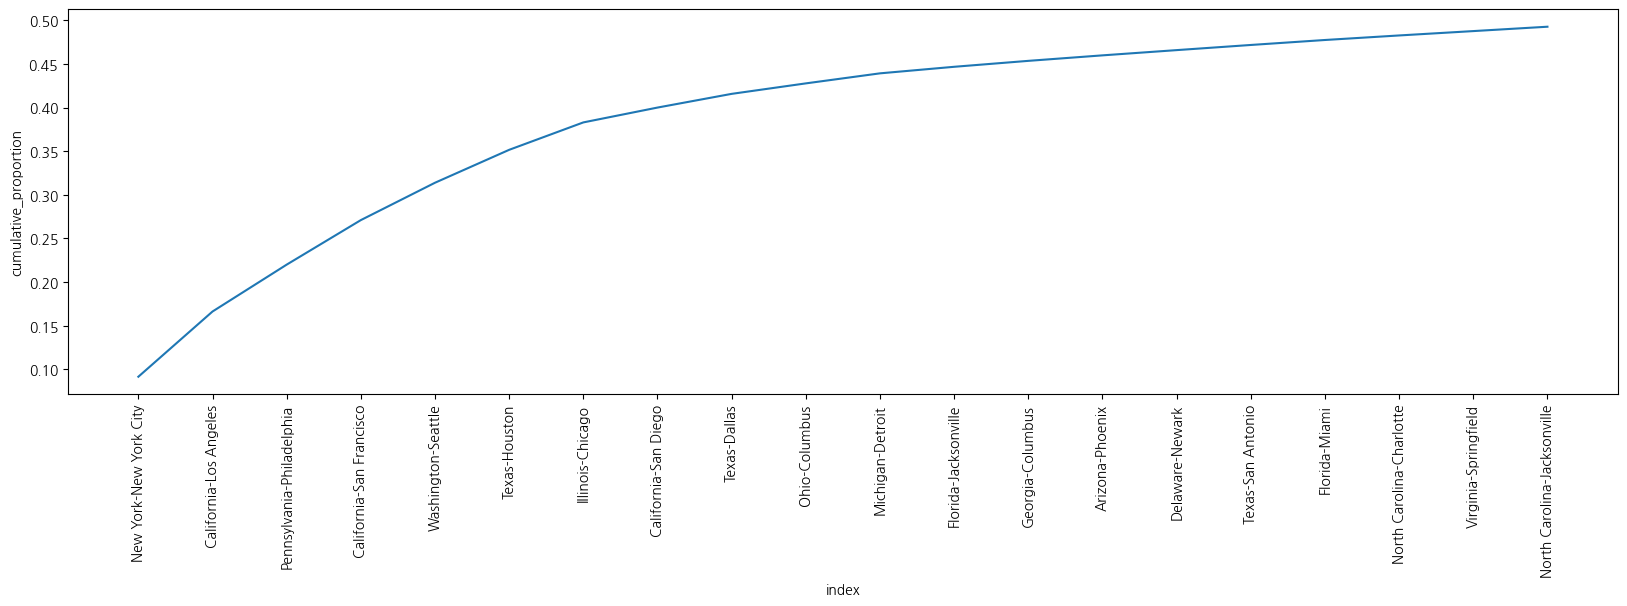

,index,count,proportion,cumulative_count,cumulative_proportion
0,New York-New York City,915,0.09,915,0.09
1,California-Los Angeles,747,0.07,1662,0.17
2,Pennsylvania-Philadelphia,537,0.05,2199,0.22
3,California-San Francisco,510,0.05,2709,0.27
4,Washington-Seattle,428,0.04,3137,0.31
5,Texas-Houston,377,0.04,3514,0.35
6,Illinois-Chicago,314,0.03,3828,0.38
7,California-San Diego,170,0.02,3998,0.40
8,Texas-Dallas,157,0.02,4155,0.42
9,Ohio-Columbus,120,0.01,4275,0.43


In [ ]:
# City and State
tmp = df['State' ] + "-" + df['City']  #df[['City', 'State']].nunique()
tmp = tmp.value_counts().reset_index()
tmp['proportion'] = tmp['count'] / tmp['count'].sum()
tmp['cumulative_count'] = tmp['count'].cumsum()  # 누적 합 추가
tmp['cumulative_proportion'] = tmp['proportion'].cumsum()  # 누적 비율 추가

plt.figure(figsize = (20,5))
sns.lineplot(data = tmp.nlargest(20, 'count'), x = 'index', y = 'cumulative_proportion')
plt.xticks(rotation = 90)
plt.show()

tmp.nlargest(20, 'count')

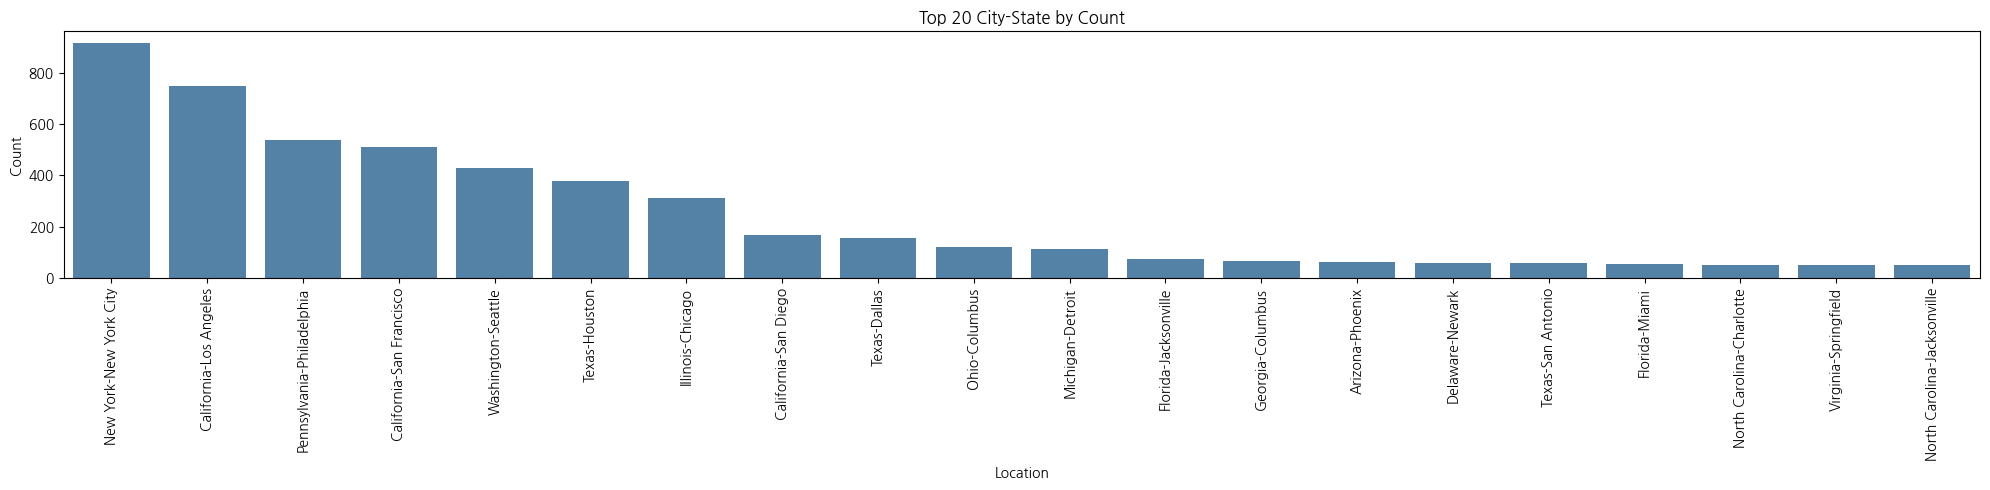

In [ ]:
tmp = df['State'] + "-" + df['City']
tmp = tmp.value_counts().reset_index()
tmp.columns = ['location', 'count']
tmp['proportion'] = tmp['count'] / tmp['count'].sum()
tmp['cumulative_count'] = tmp['count'].cumsum()
tmp['cumulative_proportion'] = tmp['proportion'].cumsum()

# 상위 20개만 추출
top_tmp = tmp.nlargest(20, 'count')

# 시각화
plt.figure(figsize=(20, 5))
sns.barplot(data=top_tmp, x='location', y='count', color='steelblue')
plt.xticks(rotation=90)
plt.title('Top 20 City-State by Count')
plt.xlabel('Location')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

,count
Region,
West,3202
East,2848
Central,2323
South,1620


<Axes: xlabel='Region', ylabel='count'>

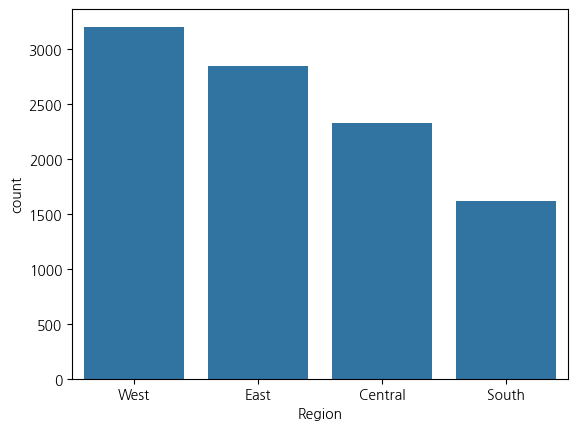

In [ ]:
# Region
display(df['Region'].value_counts())
sns.countplot(data = df, x = 'Region', order = df['Region'].value_counts().index)

In [ ]:
# drill down
# region > state > city

,count
Category,
Office Supplies,6025
Furniture,2121
Technology,1847


<Axes: xlabel='Category', ylabel='count'>

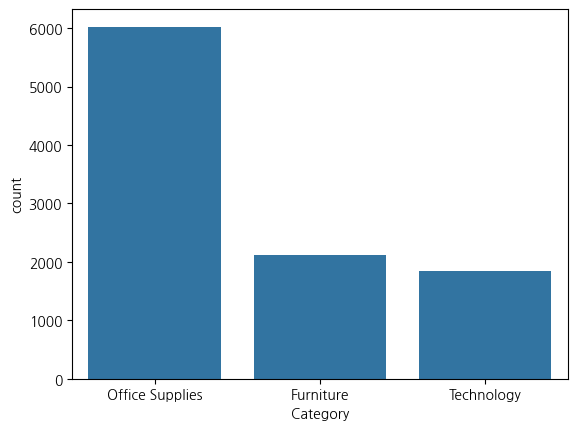

In [ ]:
# Category
display(df['Category'].value_counts())
sns.countplot(data = df, x = 'Category', order = df['Category'].value_counts().index)

,Sub-Category,count
0,Binders,1523
1,Paper,1370
2,Furnishings,957
3,Phones,889
4,Storage,846
5,Art,796
6,Accessories,775
7,Chairs,617
8,Appliances,465
9,Labels,364


<Axes: xlabel='Sub-Category', ylabel='count'>

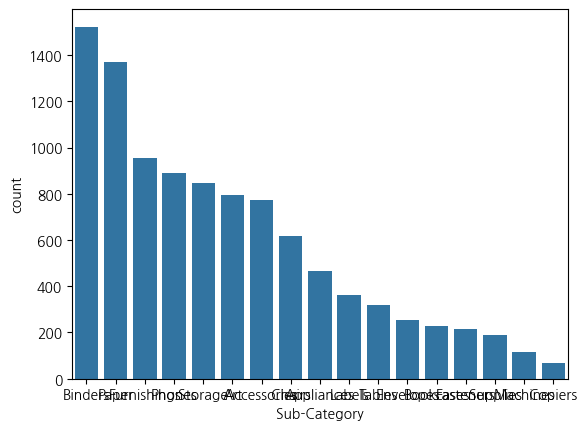

In [ ]:
# Sub-Category
display(df['Sub-Category'].value_counts().reset_index())
sns.countplot(data = df, x = 'Sub-Category', order= df['Sub-Category'].value_counts().index)

In [ ]:
# numeric type
df.describe(exclude = 'object')

,Postal Code,Sales,Quantity,Discount,Profit
count,9993.00,9993.00,9993.00,9993.00,9993.00
mean,55186.63,229.86,3.79,0.16,28.65
std,32063.10,623.28,2.23,0.21,234.27
min,1040.00,0.44,1.00,0.00,-6599.98
25%,23223.00,17.28,2.00,0.00,1.73
50%,56301.00,54.48,3.00,0.20,8.66
75%,90008.00,209.94,5.00,0.20,29.36
max,99301.00,22638.48,14.00,0.80,8399.98


<Axes: >

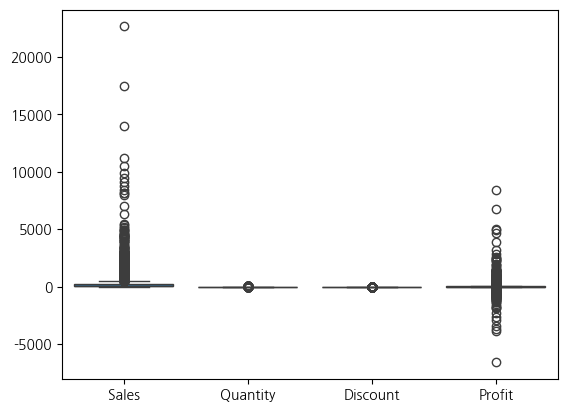

In [ ]:
# numeric type nuniques
tmp = df.select_dtypes(include = 'number')[['Sales', 'Quantity', 'Discount', 'Profit']]
sns.boxplot(tmp)

In [ ]:
# postal code : 큰 특이사항 없이 진행하겠습니다.
df.describe(exclude = 'object').isna().sum()

,0
Postal Code,0
Sales,0
Quantity,0
Discount,0
Profit,0


<Axes: ylabel='Sales'>

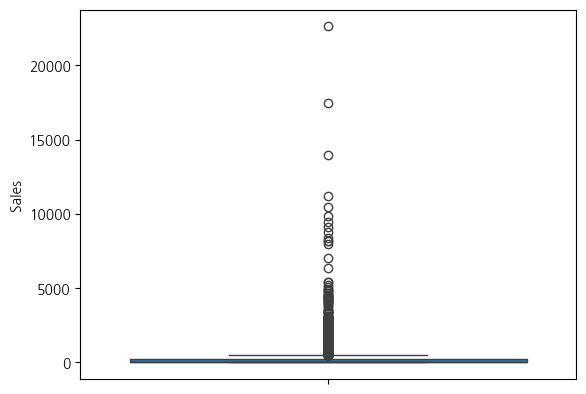

In [ ]:
# Sales :
sns.boxplot(df['Sales'])

<Axes: xlabel='Sales', ylabel='Count'>

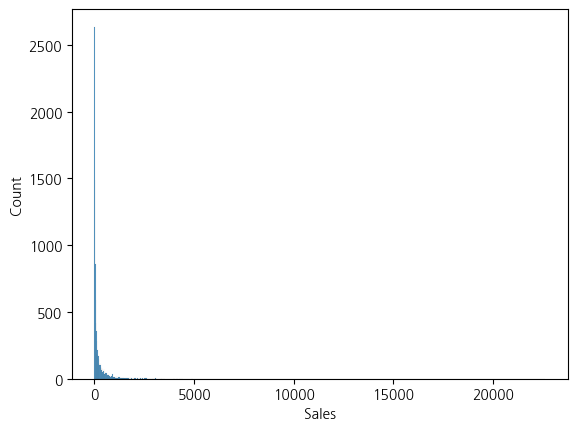

In [ ]:
sns.histplot(df['Sales'])

In [ ]:
df.sort_values(by = 'Sales', ascending= False).head(10)

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
2697,Standard Class,Home Office,United States,Jacksonville,Florida,32216,South,Technology,Machines,22638.48,6,0.50,-1811.08
6826,Standard Class,Corporate,United States,Lafayette,Indiana,47905,Central,Technology,Copiers,17499.95,5,0.00,8399.98
8153,First Class,Consumer,United States,Seattle,Washington,98115,West,Technology,Copiers,13999.96,4,0.00,6719.98
2623,First Class,Home Office,United States,New York City,New York,10024,East,Technology,Copiers,11199.97,4,0.20,3919.99
4190,Standard Class,Consumer,United States,Newark,Delaware,19711,East,Technology,Copiers,10499.97,3,0.00,5039.99
9039,Standard Class,Consumer,United States,Detroit,Michigan,48205,Central,Office Supplies,Binders,9892.74,13,0.00,4946.37
4098,Standard Class,Consumer,United States,Minneapolis,Minnesota,55407,Central,Office Supplies,Binders,9449.95,5,0.00,4630.48
4277,Standard Class,Corporate,United States,Lakewood,New Jersey,8701,East,Technology,Machines,9099.93,7,0.00,2365.98
8488,Second Class,Consumer,United States,Arlington,Virginia,22204,South,Technology,Machines,8749.95,5,0.00,2799.98
6425,Standard Class,Consumer,United States,Philadelphia,Pennsylvania,19120,East,Technology,Copiers,8399.98,4,0.40,1120.00


<Axes: ylabel='Quantity'>

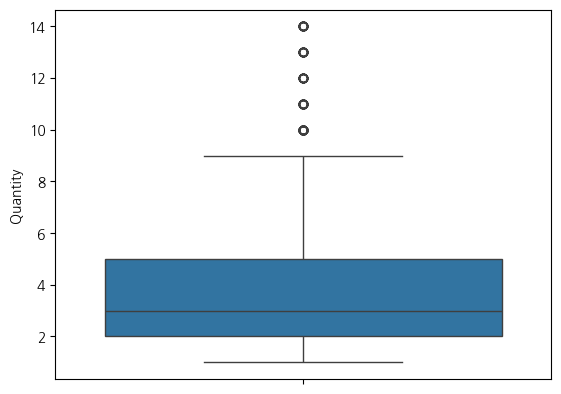

In [ ]:
# Quantity
sns.boxplot(df['Quantity'])

<Axes: xlabel='Quantity', ylabel='count'>

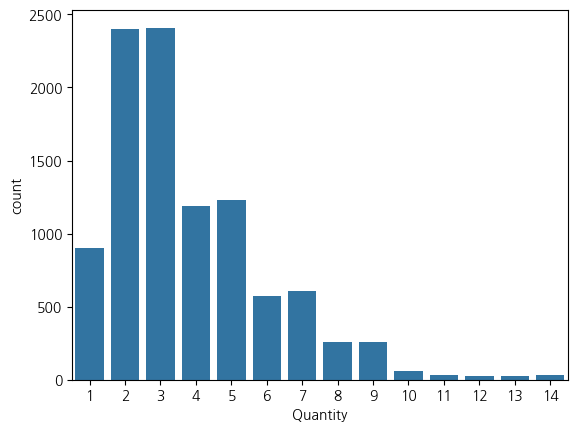

In [ ]:
sns.barplot(df['Quantity'].value_counts().sort_index())

<Axes: ylabel='Discount'>

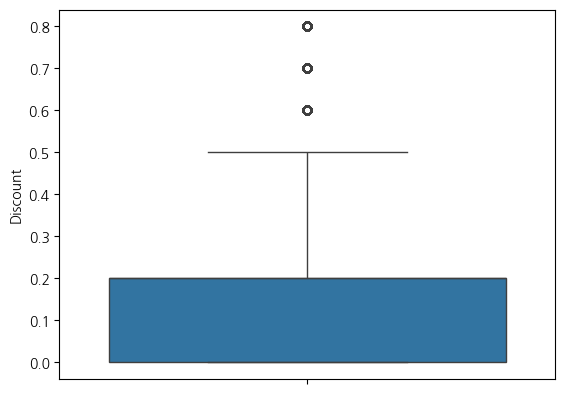

In [ ]:
# Discount
sns.boxplot(df['Discount'])

<Axes: xlabel='Discount', ylabel='count'>

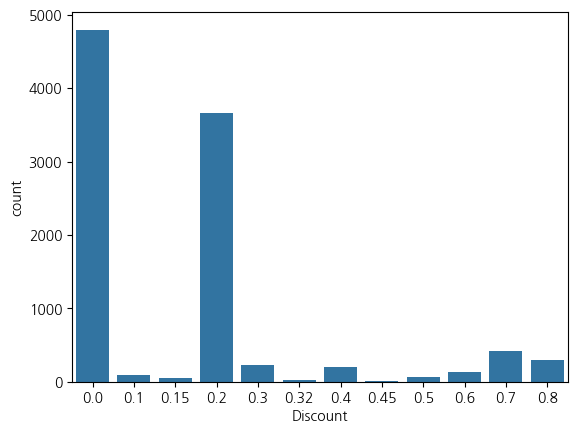

In [ ]:
sns.barplot(df['Discount'].value_counts().sort_index())

<Axes: ylabel='Profit'>

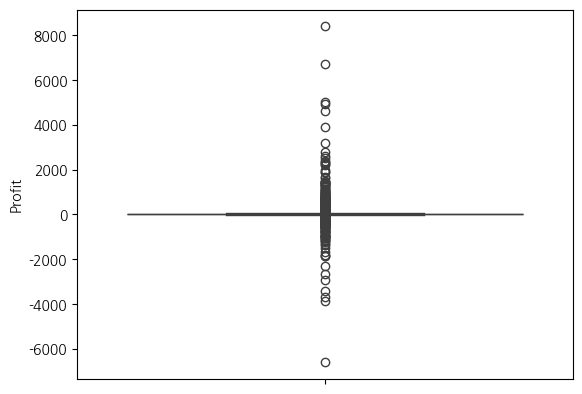

In [ ]:
# Profit
sns.boxplot(df['Profit'])

# Analysis
- 최근 몇달 : date data 가 없으므로 기간 x 동안 판매 내역이라 가정하여 분석을 진행하겠습니다.

- 1 : 더딘 매출 및 수익 증가 원인 분석
    - 1순위 지표 : 수익률 : Rate_of_return = Profit / Sales
    - 2순위 지표 : 매출 : Sales
    - 3순위 지표 : 수익 : Profit

- 2
    - Discount 항목은 의미 확인이 어려워 분석 과정에서 제외 후 진행하겠습니다.
    - 예시로, abs(Sales * Discount) 값이 Profit 값과 불일치 확인, 결론적으로 Discount 값이 어떤 의미를 가지는지 데이터 상으로 파악이 어렵습니다.
    - Quantity : 상품단가 산출 또는 구매 수 추세 파악 위한 항목으로 검토하겠습니다.

- 3
    - 상기 분석 과정서 파악된 원인 개선 위한 상시모니터링 대시보드 제안

- 4
    - 총 4가지 관점에서 분석을 수행하여 인사이트 파악에 집중하였습니다.
        - Sales, Profit Trend
            - Aspect 1 : Ship Mode
            - Aspect 2 : Segment
            - Aspect 3 : Region > State > City
            - Aspect 4 : Category > Sub-Category

In [ ]:
df.select_dtypes(include = 'number')

,Postal Code,Sales,Quantity,Discount,Profit
0,42420,261.96,2,0.00,41.91
1,42420,731.94,3,0.00,219.58
2,90036,14.62,2,0.00,6.87
3,33311,957.58,5,0.45,-383.03
4,33311,22.37,2,0.20,2.52
...,...,...,...,...,...
9988,30605,206.10,5,0.00,55.65
9989,33180,25.25,3,0.20,4.10
9990,92627,91.96,2,0.00,15.63
9991,92627,258.58,2,0.20,19.39


In [ ]:
df.select_dtypes(include = 'object')

,Ship Mode,Segment,Country,City,State,Region,Category,Sub-Category
0,Second Class,Consumer,United States,Henderson,Kentucky,South,Furniture,Bookcases
1,Second Class,Consumer,United States,Henderson,Kentucky,South,Furniture,Chairs
2,Second Class,Corporate,United States,Los Angeles,California,West,Office Supplies,Labels
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,South,Furniture,Tables
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,South,Office Supplies,Storage
...,...,...,...,...,...,...,...,...
9988,Standard Class,Corporate,United States,Athens,Georgia,South,Technology,Phones
9989,Second Class,Consumer,United States,Miami,Florida,South,Furniture,Furnishings
9990,Standard Class,Consumer,United States,Costa Mesa,California,West,Furniture,Furnishings
9991,Standard Class,Consumer,United States,Costa Mesa,California,West,Technology,Phones


## Sales, Profit Trend

### - Aspect 1 : Ship Mode
- target : Standard Class

In [ ]:
tmp = df.groupby('Ship Mode')[['Sales', 'Profit']].sum()
tmp = tmp.reset_index()
tmp['Sales_proportion'] = tmp['Sales'] / tmp['Sales'].sum()
tmp['Profit_proportion'] = tmp['Profit'] / tmp['Profit'].sum()
tmp['Rate_of_return'] = tmp['Profit'] / tmp['Sales']

# 누적비율 전 인덱스 조정
tmp = tmp.sort_values(by = ['Rate_of_return', 'Sales', 'Profit'], ascending = [False, False, False]).reset_index(drop = True)

# 누적비율 추가
tmp['cumulative_Sales_proportion'] = tmp['Sales_proportion'].cumsum()
tmp['cumulative_Profit_proportion'] = tmp['Profit_proportion'].cumsum()

tmp.head(10).style.background_gradient(cmap = 'coolwarm', subset=['Rate_of_return'])

,Ship Mode,Sales,Profit,Sales_proportion,Profit_proportion,Rate_of_return,cumulative_Sales_proportion,cumulative_Profit_proportion
0,First Class,351428.422900,48969.839900,0.152997,0.171029,0.139345,0.152997,0.171029
1,Second Class,458950.409400,57373.687400,0.199808,0.200380,0.125011,0.352805,0.371410
2,Same Day,128363.125000,15891.758900,0.055884,0.055503,0.123803,0.408689,0.426912
3,Standard Class,1358215.743000,164088.787500,0.591311,0.573088,0.120812,1.000000,1.000000


In [ ]:
# Melt
tmp_melt = tmp.melt(id_vars = tmp.columns[0], value_vars = ['Sales_proportion', 'Profit_proportion'], var_name = 'Category', value_name = 'Value')
tmp_melt

,Ship Mode,Category,Value
0,First Class,Sales_proportion,0.15
1,Second Class,Sales_proportion,0.20
2,Same Day,Sales_proportion,0.06
3,Standard Class,Sales_proportion,0.59
4,First Class,Profit_proportion,0.17
5,Second Class,Profit_proportion,0.20
6,Same Day,Profit_proportion,0.06
7,Standard Class,Profit_proportion,0.57


,Ship Mode,Sales,Profit,Sales_proportion,Profit_proportion,Rate_of_return,cumulative_Sales_proportion,cumulative_Profit_proportion
0,First Class,351428.422900,48969.839900,0.152997,0.171029,0.139345,0.152997,0.171029
1,Second Class,458950.409400,57373.687400,0.199808,0.200380,0.125011,0.352805,0.371410
2,Same Day,128363.125000,15891.758900,0.055884,0.055503,0.123803,0.408689,0.426912
3,Standard Class,1358215.743000,164088.787500,0.591311,0.573088,0.120812,1.000000,1.000000


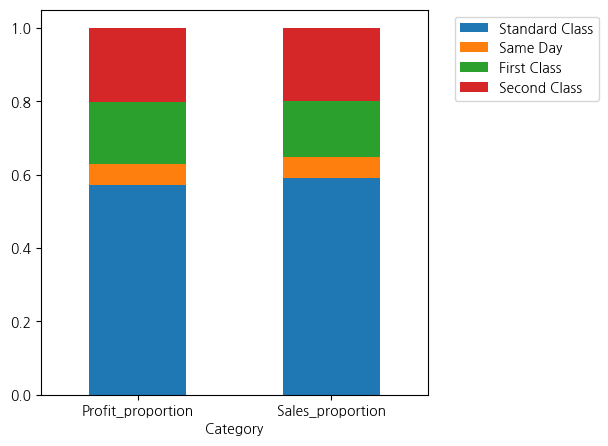

In [ ]:
# Standard Class 에서 50% 이상의 Profit, Sales 발생 확인
# 일반 옵션(가정) 에 해당하는 Standard Class 인 만큼 해당 옵션의 수익성 개선은 장기적인 측면에서 검토가 필요할 것으로 사료됩니다.

import matplotlib.pyplot as plt
%matplotlib inline

# pivot
pivot_df = tmp_melt.pivot(index='Category', columns='Ship Mode', values='Value')
pivot_df = pivot_df[['Standard Class', 'Same Day', 'First Class', 'Second Class']]
display(tmp.head(10).style.background_gradient(cmap = 'coolwarm', subset=['Rate_of_return']))

# Stacked Bar Chart
pivot_df.plot.bar(stacked=True, figsize=(5,5))
plt.xticks(rotation = 0)
plt.legend(bbox_to_anchor = (1.05, 1))
plt.show()


### - Aspect 2 : Segment
- target : Consumer


In [ ]:
tmp = df.groupby('Segment')[['Sales', 'Profit']].sum()
tmp = tmp.reset_index()
tmp['Sales_proportion'] = tmp['Sales'] / tmp['Sales'].sum()
tmp['Profit_proportion'] = tmp['Profit'] / tmp['Profit'].sum()
tmp['Rate_of_return'] = tmp['Profit'] / tmp['Sales']

# 누적비율 전 인덱스 조정
tmp = tmp.sort_values(by = ['Rate_of_return', 'Sales', 'Profit'], ascending = [False, False, False]).reset_index(drop = True)

# 누적비율 추가
tmp['cumulative_Sales_proportion'] = tmp['Sales_proportion'].cumsum()
tmp['cumulative_Profit_proportion'] = tmp['Profit_proportion'].cumsum()

tmp.head(10).style.background_gradient(cmap = 'coolwarm', subset=['Rate_of_return'])

,Segment,Sales,Profit,Sales_proportion,Profit_proportion,Rate_of_return,cumulative_Sales_proportion,cumulative_Profit_proportion
0,Home Office,429653.148500,60298.678500,0.187053,0.210596,0.140343,0.187053,0.210596
1,Corporate,706146.366800,91979.134000,0.307427,0.321241,0.130255,0.494480,0.531837
2,Consumer,1161158.185000,134046.261200,0.505520,0.468163,0.115442,1.000000,1.000000


In [ ]:
# Melt
tmp_melt = tmp.melt(id_vars = tmp.columns[0], value_vars = ['Sales_proportion', 'Profit_proportion'], var_name = 'Category', value_name = 'Value')
tmp_melt

,Segment,Category,Value
0,Home Office,Sales_proportion,0.19
1,Corporate,Sales_proportion,0.31
2,Consumer,Sales_proportion,0.51
3,Home Office,Profit_proportion,0.21
4,Corporate,Profit_proportion,0.32
5,Consumer,Profit_proportion,0.47


,Segment,Sales,Profit,Sales_proportion,Profit_proportion,Rate_of_return,cumulative_Sales_proportion,cumulative_Profit_proportion
0,Home Office,429653.148500,60298.678500,0.187053,0.210596,0.140343,0.187053,0.210596
1,Corporate,706146.366800,91979.134000,0.307427,0.321241,0.130255,0.494480,0.531837
2,Consumer,1161158.185000,134046.261200,0.505520,0.468163,0.115442,1.000000,1.000000


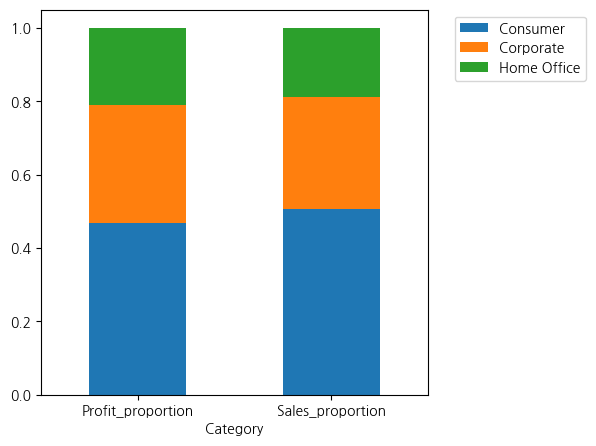

In [ ]:
# 가장 낮은 수익성을 보인 Segment Consumer 최우선 개선 대상으로 제안 드립니다.

# pivot
pivot_df = tmp_melt.pivot(index='Category', columns='Segment', values='Value')
display(tmp.head(10).style.background_gradient(cmap = 'coolwarm', subset=['Rate_of_return']))

# Stacked Bar Chart
pivot_df.plot.bar(stacked=True, figsize=(5,5))
plt.xticks(rotation = 0)
plt.legend(bbox_to_anchor = (1.05, 1))
plt.show()

### - Aspect 3 : Region > State > City

In [ ]:
# step1 : Region

tmp = df.groupby('Region')[['Sales', 'Profit']].sum()
tmp = tmp.reset_index()
tmp['Sales_proportion'] = tmp['Sales'] / tmp['Sales'].sum()
tmp['Profit_proportion'] = tmp['Profit'] / tmp['Profit'].sum()
tmp['Rate_of_return'] = tmp['Profit'] / tmp['Sales']

# 누적비율 전 인덱스 조정
tmp = tmp.sort_values(by = ['Rate_of_return', 'Sales', 'Profit'], ascending = [False, False, False]).reset_index(drop = True)

# 누적비율 추가
tmp['cumulative_Sales_proportion'] = tmp['Sales_proportion'].cumsum()
tmp['cumulative_Profit_proportion'] = tmp['Profit_proportion'].cumsum()

tmp.head(10).style.background_gradient(cmap = 'coolwarm', subset=['Rate_of_return'])

,Region,Sales,Profit,Sales_proportion,Profit_proportion,Rate_of_return,cumulative_Sales_proportion,cumulative_Profit_proportion
0,West,725214.664500,108345.500900,0.315728,0.378402,0.149398,0.315728,0.378402
1,East,678781.240000,91522.780000,0.295513,0.319648,0.134834,0.611242,0.698049
2,South,391721.905000,46749.430300,0.170539,0.163275,0.119343,0.781781,0.861324
3,Central,501239.890800,39706.362500,0.218219,0.138676,0.079216,1.000000,1.000000


In [ ]:
# Melt
tmp_melt = tmp.melt(id_vars = tmp.columns[0], value_vars = ['Sales_proportion', 'Profit_proportion'], var_name = 'Category', value_name = 'Value')
tmp_melt


,Region,Category,Value
0,West,Sales_proportion,0.32
1,East,Sales_proportion,0.30
2,South,Sales_proportion,0.17
3,Central,Sales_proportion,0.22
4,West,Profit_proportion,0.38
5,East,Profit_proportion,0.32
6,South,Profit_proportion,0.16
7,Central,Profit_proportion,0.14


,Region,Sales,Profit,Sales_proportion,Profit_proportion,Rate_of_return,cumulative_Sales_proportion,cumulative_Profit_proportion
0,West,725214.664500,108345.500900,0.315728,0.378402,0.149398,0.315728,0.378402
1,East,678781.240000,91522.780000,0.295513,0.319648,0.134834,0.611242,0.698049
2,South,391721.905000,46749.430300,0.170539,0.163275,0.119343,0.781781,0.861324
3,Central,501239.890800,39706.362500,0.218219,0.138676,0.079216,1.000000,1.000000


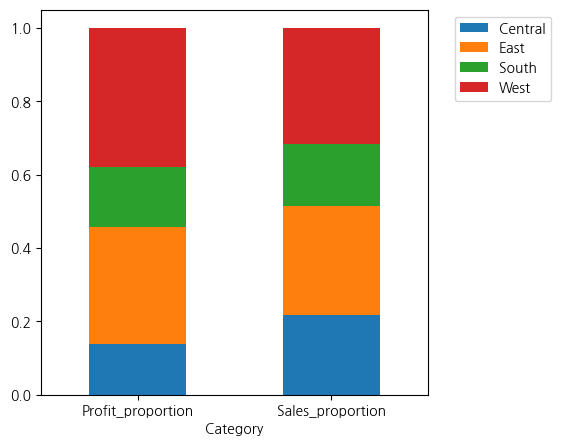

In [ ]:
# Region : Central 의 수익성 개선 대상 1순위 Region 으로 선정, 해당 지역에 대한 추가 분석을 수행합니다.

# pivot
pivot_df = tmp_melt.pivot(index='Category', columns=tmp.columns[0], values='Value')
display(tmp.head(10).style.background_gradient(cmap = 'coolwarm', subset=['Rate_of_return']))

# # Stacked Bar Chart
pivot_df.plot.bar(stacked=True, figsize=(5,5))
plt.xticks(rotation = 0)
plt.legend(bbox_to_anchor = (1.05, 1))
plt.show()


### - Aspect 3 - 1 : Region (Central) > State

In [ ]:
# step2 : Region digging to State
# Central 지역의 수익성 개선 시급 States는 음의 수익을 보이는 Texas, Illinois 를 제안드립니다.
# 위 2개 States 포함 개선 시급 top 10은 아래와 같으며 해당 지역에 대한 수익 개선을 최 우선으로 제안 드립니다.
# ['Texas', 'Illinois', 'Michigan', 'Indiana', 'Wisconsin', 'Minnesota', 'Missouri', 'Oklahoma', 'Nebraska', 'Iowa']
# top 10 States의 City 단위 인사이트 확보를 위해 추가 분석을 수행합니다.

tmp = df[df['Region'] == 'Central']
tmp = tmp.groupby('State')[['Sales', 'Profit']].sum()
tmp = tmp.reset_index()
tmp['Sales_proportion'] = tmp['Sales'] / tmp['Sales'].sum()
tmp['Profit_proportion'] = tmp['Profit'] / tmp['Profit'].sum()
tmp['Rate_of_return'] = tmp['Profit'] / tmp['Sales']

# 누적비율 전 인덱스 조정
tmp = tmp.sort_values(by = ['Sales', 'Profit', 'Rate_of_return'], ascending = [False, True, True]).reset_index(drop = True)

# 누적비율 추가
tmp['cumulative_Sales_proportion'] = tmp['Sales_proportion'].cumsum()
tmp['cumulative_Profit_proportion'] = tmp['Profit_proportion'].cumsum()

tmp.head(10).style.background_gradient(cmap = 'coolwarm', subset=['Rate_of_return'])

,State,Sales,Profit,Sales_proportion,Profit_proportion,Rate_of_return,cumulative_Sales_proportion,cumulative_Profit_proportion
0,Texas,170188.045800,-25729.356300,0.339534,-0.647991,-0.151182,0.339534,-0.647991
1,Illinois,80166.101000,-12607.887000,0.159936,-0.317528,-0.157272,0.499470,-0.965519
2,Michigan,76269.614000,24463.187600,0.152162,0.616102,0.320746,0.651632,-0.349416
3,Indiana,53555.360000,18382.936300,0.106846,0.462972,0.343251,0.758477,0.113556
4,Wisconsin,32114.610000,8401.800400,0.064070,0.211598,0.261619,0.822548,0.325154
5,Minnesota,29863.150000,10823.187400,0.059579,0.272581,0.362426,0.882126,0.597735
6,Missouri,22205.150000,6436.210500,0.044300,0.162095,0.289852,0.926427,0.759830
7,Oklahoma,19683.390000,4853.956000,0.039269,0.122246,0.246602,0.965696,0.882076
8,Nebraska,7464.930000,2037.094200,0.014893,0.051304,0.272889,0.980589,0.933380
9,Iowa,4579.760000,1183.811900,0.009137,0.029814,0.258488,0.989726,0.963194


In [ ]:
print(tmp.head(10)['State'].tolist())

['Texas', 'Illinois', 'Michigan', 'Indiana', 'Wisconsin', 'Minnesota', 'Missouri', 'Oklahoma', 'Nebraska', 'Iowa']


### - Aspect 3 - 2 : Region (Central) > State (need to improve) > City
* target states : ['Texas', 'Illinois', 'North Dakota', 'South Dakota', 'Kansas', 'Iowa', 'Nebraska', 'Oklahoma', 'Missouri', 'Wisconsin']


In [ ]:
# step3 : State digging to Cities
# Central 지역, 대상 States 의 수익성 개선 시급 City는 음의 수익을 보이는 Houston, Chicago, San Antonio, Dallas 제안드립니다.
# 위 4개 City 포함 개선 시급 top 10은 아래와 같으며 해당 지역에 대한 수익 개선을 최 우선으로 제안 드립니다.
# ['Houston', 'Chicago', 'Detroit', 'San Antonio', 'Dallas', 'Lafayette', 'Minneapolis', 'Jackson', 'Springfield', 'Milwaukee']

State_need_to_improve = ['Texas', 'Illinois', 'Michigan', 'Indiana', 'Wisconsin', 'Minnesota', 'Missouri', 'Oklahoma', 'Nebraska', 'Iowa']

tmp = df[df['State'].isin(State_need_to_improve)]
tmp = tmp.groupby('City')[['Sales', 'Profit']].sum()
tmp = tmp.reset_index()
tmp['Sales_proportion'] = tmp['Sales'] / tmp['Sales'].sum()
tmp['Profit_proportion'] = tmp['Profit'] / tmp['Profit'].sum()
tmp['Rate_of_return'] = tmp['Profit'] / tmp['Sales']

# 누적비율 전 인덱스 조정
tmp = tmp.sort_values(by = ['Sales', 'Profit', 'Rate_of_return'], ascending = [False, True, True]).reset_index(drop = True)

# 누적비율 추가
tmp['cumulative_Sales_proportion'] = tmp['Sales_proportion'].cumsum()
tmp['cumulative_Profit_proportion'] = tmp['Profit_proportion'].cumsum()

tmp.head(10).style.background_gradient(cmap = 'coolwarm', subset=['Rate_of_return'])

,City,Sales,Profit,Sales_proportion,Profit_proportion,Rate_of_return,cumulative_Sales_proportion,cumulative_Profit_proportion
0,Houston,64504.760400,-10153.548500,0.130026,-0.265487,-0.157408,0.130026,-0.265487
1,Chicago,48539.541000,-6654.568800,0.097844,-0.173999,-0.137096,0.227870,-0.439486
2,Detroit,42446.944000,13181.790800,0.085563,0.344668,0.310547,0.313433,-0.094818
3,San Antonio,21843.528000,-7299.050200,0.044031,-0.190850,-0.334152,0.357465,-0.285669
4,Dallas,20131.932200,-2846.525700,0.040581,-0.074429,-0.141394,0.398046,-0.360097
5,Lafayette,19630.450000,8976.097300,0.039570,0.234700,0.457254,0.437616,-0.125397
6,Minneapolis,16870.540000,6824.584600,0.034007,0.178444,0.404527,0.471623,0.053047
7,Jackson,15420.036000,5525.199200,0.031083,0.144469,0.358313,0.502707,0.197516
8,Springfield,15051.380000,3905.589100,0.030340,0.102120,0.259484,0.533047,0.299636
9,Milwaukee,11410.220000,2793.085100,0.023000,0.073031,0.244788,0.556047,0.372668


In [ ]:
print(tmp.head(10)['City'].tolist())

['Houston', 'Chicago', 'Detroit', 'San Antonio', 'Dallas', 'Lafayette', 'Minneapolis', 'Jackson', 'Springfield', 'Milwaukee']


### - Aspect 3 - 3 : Finalize

- Need to Care to improve rate of return
    - Region = 'Central'
    - State = ['Texas', 'Illinois', 'Michigan', 'Indiana', 'Wisconsin', 'Minnesota', 'Missouri', 'Oklahoma', 'Nebraska', 'Iowa']
    - City = ['Houston', 'Chicago', 'Detroit', 'San Antonio', 'Dallas', 'Lafayette', 'Minneapolis', 'Jackson', 'Springfield', 'Milwaukee']


- 위 타깃 중점으로 Category, Sub-Category 측면에서의 개선 인사이트 확보를 위한 분석을 수행 하겠습니다.

In [ ]:
# variable
Region = 'Central'
State = ['Texas', 'Illinois', 'Michigan', 'Indiana', 'Wisconsin', 'Minnesota', 'Missouri', 'Oklahoma', 'Nebraska', 'Iowa']
City = ['Houston', 'Chicago', 'Detroit', 'San Antonio', 'Dallas', 'Lafayette', 'Minneapolis', 'Jackson', 'Springfield', 'Milwaukee']

df_filtered = df[df['Region'] == Region]
df_filtered = df_filtered[df_filtered['State'].isin(State)]
df_filtered = df_filtered[df_filtered['City'].isin(City)]
df_filtered[['Region', 'State', 'City']].value_counts()

# check state
df_filtered[['Region', 'State', 'City']].value_counts().reset_index().sort_values(by = ['State', 'City', 'count'], ascending = [False, False, False])

,Region,State,City,count
5,Central,Wisconsin,Milwaukee,45
4,Central,Texas,San Antonio,59
0,Central,Texas,Houston,377
2,Central,Texas,Dallas,157
6,Central,Missouri,Springfield,39
8,Central,Minnesota,Minneapolis,23
7,Central,Michigan,Jackson,38
3,Central,Michigan,Detroit,115
9,Central,Indiana,Lafayette,12
1,Central,Illinois,Chicago,314


### - Aspect 4 : Category

In [ ]:
# step1 : Category
# 수익성 개선 시급 카테고리로서 음의 수익성 보이는 Office Supplies, Furniture 제안드립니다.

tmp = df_filtered.groupby('Category')[['Sales', 'Profit']].sum()
tmp = tmp.reset_index()
tmp['Sales_proportion'] = tmp['Sales'] / tmp['Sales'].sum()
tmp['Profit_proportion'] = tmp['Profit'] / tmp['Profit'].sum()
tmp['Rate_of_return'] = tmp['Profit'] / tmp['Sales']

# 누적비율 전 인덱스 조정
tmp = tmp.sort_values(by = ['Sales', 'Profit', 'Rate_of_return'], ascending = [False, True, True]).reset_index(drop = True)

# 누적비율 추가
tmp['cumulative_Sales_proportion'] = tmp['Sales_proportion'].cumsum()
tmp['cumulative_Profit_proportion'] = tmp['Profit_proportion'].cumsum()

tmp.head(10).style.background_gradient(cmap = 'coolwarm', subset=['Rate_of_return'])

,Category,Sales,Profit,Sales_proportion,Profit_proportion,Rate_of_return,cumulative_Sales_proportion,cumulative_Profit_proportion
0,Technology,106645.954000,19673.138900,0.386609,1.380314,0.184471,0.386609,1.380314
1,Office Supplies,89882.757000,-2719.940600,0.325840,-0.190837,-0.030261,0.712449,1.189477
2,Furniture,79320.620600,-2700.545400,0.287551,-0.189477,-0.034046,1.000000,1.000000


### - Aspect 4 - 1: Category > Sub-Category

In [ ]:
# drill down from Category to Sub-Category

# Sub-Category 고려하여 Sales 파워가 있고, 수익률 부분에서 음수를 보이는 4개 항목을 선별하였습니다.
# Category	Sub-Category
# Office Supplies	Binders
# Furniture	Tables
# Furniture	Bookcases
# Office Supplies	Appliances

tmp = df_filtered.groupby(['Category', 'Sub-Category'])[['Sales', 'Profit']].sum()
tmp = tmp.reset_index()
tmp['Sales_proportion'] = tmp['Sales'] / tmp['Sales'].sum()
tmp['Profit_proportion'] = tmp['Profit'] / tmp['Profit'].sum()
tmp['Rate_of_return'] = tmp['Profit'] / tmp['Sales']

# 누적비율 전 인덱스 조정
tmp = tmp.sort_values(by = ['Sales', 'Profit', 'Rate_of_return'], ascending = [False, True, True]).reset_index(drop = True)

# 누적비율 추가
tmp['cumulative_Sales_proportion'] = tmp['Sales_proportion'].cumsum()
tmp['cumulative_Profit_proportion'] = tmp['Profit_proportion'].cumsum()

tmp[tmp['Category'].isin(['Office Supplies', 'Furniture'])].style.background_gradient(cmap = 'coolwarm', subset=['Rate_of_return'])

,Category,Sub-Category,Sales,Profit,Sales_proportion,Profit_proportion,Rate_of_return,cumulative_Sales_proportion,cumulative_Profit_proportion
0,Office Supplies,Binders,41542.048000,-2806.175700,0.150597,-0.196888,-0.067550,0.150597,-0.196888
1,Furniture,Chairs,40584.665000,2568.605400,0.147126,0.180219,0.063290,0.297723,-0.016668
5,Office Supplies,Storage,20477.528000,509.511600,0.074234,0.035749,0.024881,0.704353,1.186152
6,Furniture,Tables,19050.622000,-1116.200500,0.069062,-0.078315,-0.058591,0.773415,1.107837
8,Furniture,Bookcases,14547.625600,-1871.829100,0.052738,-0.131332,-0.128669,0.880366,1.189747
9,Office Supplies,Paper,9151.744000,3442.216400,0.033177,0.241514,0.376127,0.913543,1.431261
10,Office Supplies,Appliances,7429.195000,-5969.307700,0.026932,-0.418821,-0.803493,0.940475,1.012440
11,Furniture,Furnishings,5137.708000,-2281.121200,0.018625,-0.160049,-0.443996,0.959100,0.852391
12,Office Supplies,Supplies,4722.068000,100.076700,0.017118,0.007022,0.021193,0.976218,0.859413
13,Office Supplies,Art,2534.026000,500.884600,0.009186,0.035143,0.197664,0.985405,0.894556


In [ ]:
df_filtered[['Category', 'Sub-Category']].value_counts().reset_index().sort_values(by = ['Category', 'count'], ascending = [False, False]) .reset_index(drop = True)

,Category,Sub-Category,count
0,Technology,Phones,107
1,Technology,Accessories,86
2,Technology,Machines,16
3,Technology,Copiers,7
4,Office Supplies,Binders,187
5,Office Supplies,Paper,166
6,Office Supplies,Storage,108
7,Office Supplies,Art,84
8,Office Supplies,Appliances,65
9,Office Supplies,Labels,32
